In [2]:
#6 38 start
import pandas as pd
import  numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler


In [3]:
df=pd.read_csv("../docs/oldDocs/recruitment.csv", na_values=['/', '-', '', ' ', '_', 'NA'])

In [4]:
df.isna().sum()

Age                    0
Gender                 0
Industry               0
ExperienceYears        0
DistanceFromCompany    2
InterviewScore         2
SkillScore             0
IsEmployed             0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1500 non-null   float64
 1   Gender               1500 non-null   object 
 2   Industry             1500 non-null   object 
 3   ExperienceYears      1500 non-null   int64  
 4   DistanceFromCompany  1498 non-null   float64
 5   InterviewScore       1498 non-null   float64
 6   SkillScore           1500 non-null   int64  
 7   IsEmployed           1500 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 93.9+ KB


In [6]:
df.head()

,Age,Gender,Industry,ExperienceYears,DistanceFromCompany,InterviewScore,SkillScore,IsEmployed
0,26.0,Female,Technology,0,26.783828,48.0,78,Yes
1,39.0,Female,Technology,12,25.862694,35.0,68,Yes
2,48.0,Male,Technology,3,9.920805,20.0,67,No
3,34.0,Female,Technology,5,6.407751,36.0,27,No
4,30.0,Male,Technology,6,43.105343,23.0,52,No


In [7]:
from scipy.stats import shapiro

stats,p=shapiro(df['DistanceFromCompany'])
if p<0.05:
    print("Nije normalna")
else:
    print("jeste normalna")

jeste normalna


In [8]:
from scipy.stats import shapiro

stats,p=shapiro(df['InterviewScore'])
if p<0.05:
    print("Nije normalna")
else:
    print("jeste normalna")

jeste normalna


In [9]:
#vidimo da obe kolone koje imaju na vrednostu su normalno rasporedjene tako da menjamo sa mean vrednoscu te nan vrednosti u kolonama interviewscore i distance from company

df['InterviewScore']=df['InterviewScore'].fillna(df['InterviewScore'].mean())

In [10]:
df['DistanceFromCompany']=df['DistanceFromCompany'].fillna(df['DistanceFromCompany'].mean())


In [11]:
df.isna().sum() # sve cisto nema vise NAN

Age                    0
Gender                 0
Industry               0
ExperienceYears        0
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
IsEmployed             0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1500 non-null   float64
 1   Gender               1500 non-null   object 
 2   Industry             1500 non-null   object 
 3   ExperienceYears      1500 non-null   int64  
 4   DistanceFromCompany  1500 non-null   float64
 5   InterviewScore       1500 non-null   float64
 6   SkillScore           1500 non-null   int64  
 7   IsEmployed           1500 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 93.9+ KB


In [13]:
#kolone gender i industry su str da ih vidimo
df['Gender']

0       Female
1       Female
2         Male
3       Female
4         Male
         ...  
1495      Male
1496    Female
1497    Female
1498      Male
1499    Female
Name: Gender, Length: 1500, dtype: object

In [14]:
df['Industry'].value_counts() # vidimo da je promenjiva nomilna , i da je 99% ljudi iz iste industrije ovo nam nije bitno tako da dropujemo celu kolonu

Industry
Technology    1496
Finance          2
Healthcare       2
Name: count, dtype: int64

In [15]:
df.drop(columns='Industry',inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1500 non-null   float64
 1   Gender               1500 non-null   object 
 2   ExperienceYears      1500 non-null   int64  
 3   DistanceFromCompany  1500 non-null   float64
 4   InterviewScore       1500 non-null   float64
 5   SkillScore           1500 non-null   int64  
 6   IsEmployed           1500 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 82.2+ KB


In [17]:
#nova varijabla Hired ima vrednost 1 ako je employed
df['Hired']=np.where(df['IsEmployed']=='Yes',1,0)

In [18]:
df['Hired'].value_counts()

Hired
0    1035
1     465
Name: count, dtype: int64

In [19]:
df['IsEmployed'].value_counts()

IsEmployed
No     1035
Yes     465
Name: count, dtype: int64

In [20]:
#vidimo da smo dobro prebacili kolonu brisemo is employed
df.drop(columns='IsEmployed',inplace=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1500 non-null   float64
 1   Gender               1500 non-null   object 
 2   ExperienceYears      1500 non-null   int64  
 3   DistanceFromCompany  1500 non-null   float64
 4   InterviewScore       1500 non-null   float64
 5   SkillScore           1500 non-null   int64  
 6   Hired                1500 non-null   int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 82.2+ KB


In [22]:
#ostalo je da mapiramo Gender
df['Gender']=df['Gender'].map({'Male':1,'Female':0})

In [23]:
df['Gender'].value_counts()

Gender
1    762
0    738
Name: count, dtype: int64

In [24]:
df.isna().sum()

Age                    0
Gender                 0
ExperienceYears        0
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
Hired                  0
dtype: int64

In [25]:
df.info() # sve je spremno

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1500 non-null   float64
 1   Gender               1500 non-null   int64  
 2   ExperienceYears      1500 non-null   int64  
 3   DistanceFromCompany  1500 non-null   float64
 4   InterviewScore       1500 non-null   float64
 5   SkillScore           1500 non-null   int64  
 6   Hired                1500 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 82.2 KB


In [26]:
df.describe() # vidimo da nam treba skaliranje

,Age,Gender,ExperienceYears,DistanceFromCompany,InterviewScore,SkillScore,Hired
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,35.117600,0.508000,7.694000,25.591121,50.609479,51.116000,0.310000
std,9.284367,0.500103,4.641414,14.839492,28.598653,29.353563,0.462647
min,2.400000,0.000000,0.000000,1.031376,0.000000,0.000000,0.000000
25%,27.000000,0.000000,4.000000,12.838851,25.000000,25.750000,0.000000
50%,35.000000,1.000000,8.000000,25.591121,52.000000,53.000000,0.000000
75%,43.000000,1.000000,12.000000,37.737996,75.000000,76.000000,1.000000
max,50.000000,1.000000,15.000000,120.138742,100.000000,100.000000,1.000000


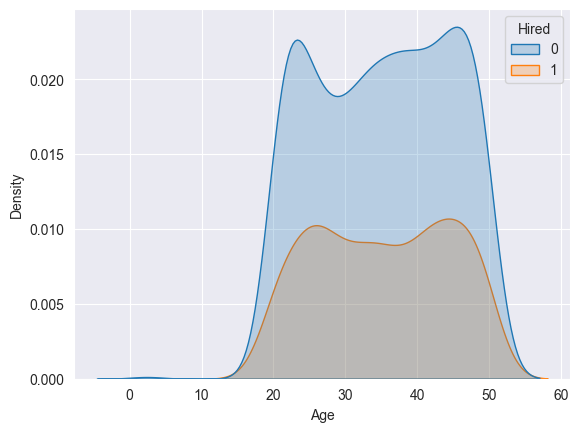

In [27]:
plt.figure()
sb.kdeplot(x=df['Age'],hue=df['Hired'],fill=True)
plt.show()
df.drop(columns='Age',inplace=True)

#vidimo da godine ne pokazuju previse neku znacajnost u odabiru kandidata , zato je dropujemo

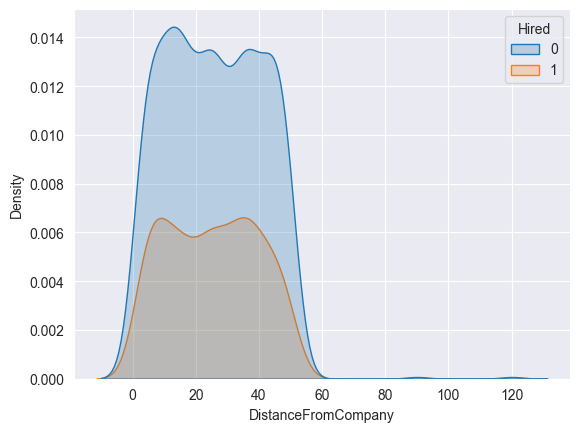

In [28]:
plt.figure()
sb.kdeplot(x=df['DistanceFromCompany'],hue=df['Hired'],fill=True)
plt.show()
#distanca razdaljine nam ne pokazuje takodje neki znacaj u zaposaljvanju zato je dropujemo i grafici se ne seku nesto
df.drop(columns='DistanceFromCompany',inplace=True)


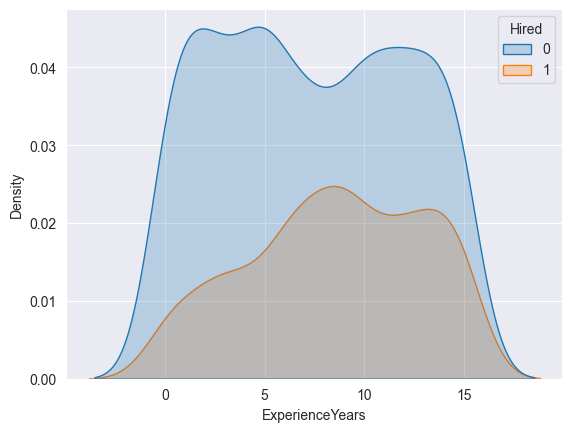

In [29]:
plt.figure()
sb.kdeplot(x=df['ExperienceYears'],hue=df['Hired'],fill=True)
plt.show()
# ne doprinosi tome da li je radnik imao iskustvo veliko ili ne koliki god mu je experience .. tako da i ovo dropujemo
df.drop(columns='ExperienceYears',inplace=True)


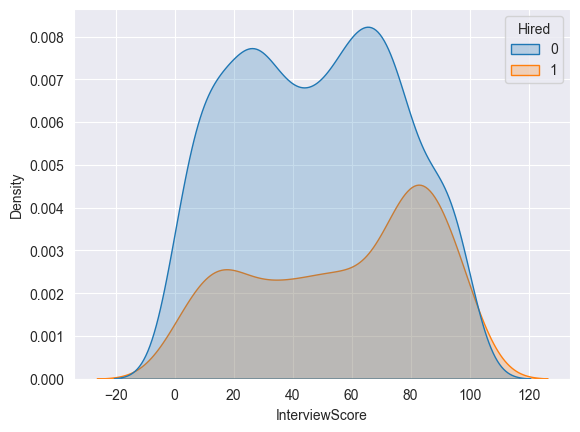

In [30]:
plt.figure()
sb.kdeplot(x=df['InterviewScore'],hue=df['Hired'],fill=True)
plt.show()
# veliki interview skore ce ipak dobrpineti da osoba bude hired tako da ostavljamo

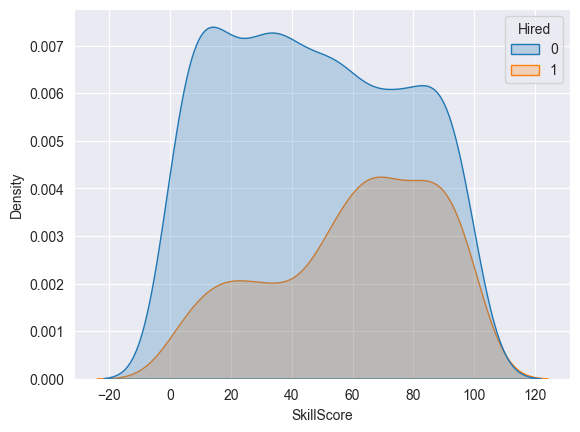

In [31]:
plt.figure()
sb.kdeplot(x=df['SkillScore'],hue=df['Hired'],fill=True)
plt.show()
#vidi da blagi skillscore ipak veliki malo doprinisi tome da li je hired

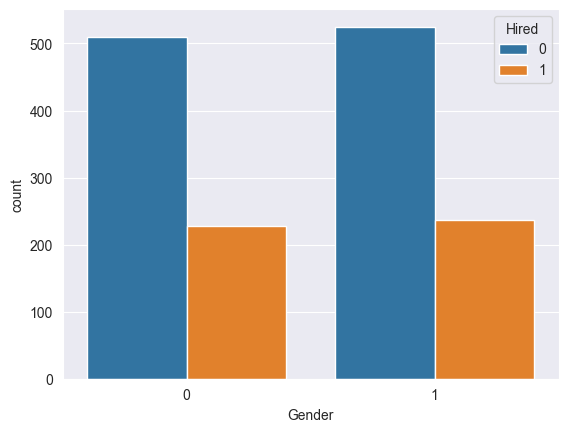

In [32]:
plt.figure()
sb.countplot(x=df['Gender'],hue=df['Hired'],fill=True)
plt.show()

#potpuno su identicne raspodele muiskarca i zena zato ne doprinisu dropujemo kolonu
df.drop(columns='Gender',inplace=True)


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   InterviewScore  1500 non-null   float64
 1   SkillScore      1500 non-null   int64  
 2   Hired           1500 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 35.3 KB


In [34]:
df.describe()#kako su poeni slicni provericemo raspodelu i outliere i videti da li treba da scaliramo

,InterviewScore,SkillScore,Hired
count,1500.000000,1500.000000,1500.000000
mean,50.609479,51.116000,0.310000
std,28.598653,29.353563,0.462647
min,0.000000,0.000000,0.000000
25%,25.000000,25.750000,0.000000
50%,52.000000,53.000000,0.000000
75%,75.000000,76.000000,1.000000
max,100.000000,100.000000,1.000000


{'whiskers': [<matplotlib.lines.Line2D at 0x1ef2320f750>,
 'caps': [<matplotlib.lines.Line2D at 0x1ef2320f9d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1ef2320f610>],
 'medians': [<matplotlib.lines.Line2D at 0x1ef2320fc50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1ef2320fd90>],
 'means': []}

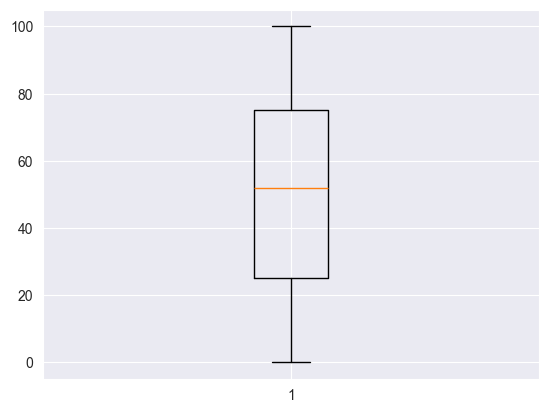

In [35]:
plt.boxplot(x=df['InterviewScore'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1ef23266850>,
 'caps': [<matplotlib.lines.Line2D at 0x1ef23266ad0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1ef23266710>],
 'medians': [<matplotlib.lines.Line2D at 0x1ef23266d50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1ef23266e90>],
 'means': []}

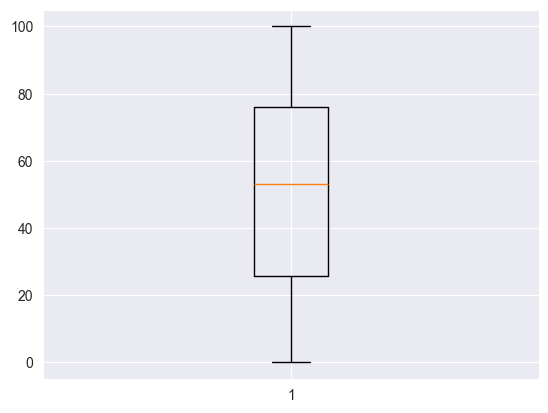

In [36]:
plt.boxplot(x=df['SkillScore'])

In [37]:
X=df.drop(columns='Hired')
y=df['Hired']

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [39]:
#uradjemo minmax scaler kako nemaju outliere
from sklearn.preprocessing import MinMaxScaler
scalerMinMax=MinMaxScaler()
df_scaled=scalerMinMax.fit_transform(X_train)


In [40]:
#sada nam treba optimalno k
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

params=[{'n_neighbors':np.arange(3,26,2)}]
knn=GridSearchCV(
        estimator=KNeighborsClassifier(),
        param_grid=params,
        verbose=1,
        cv=10,scoring='accuracy')
knn.fit(X_train,y_train)


Fitting 10 folds for each of 12 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'n_neighbors': array([ 3, 5..., 21, 23, 25])}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

In [41]:
bestK=knn.best_params_
bestK

{'n_neighbors': np.int64(21)}

In [42]:
bestK=21 # najbolje k je 21 po gridsearchu

In [43]:
ModelGlavni=KNeighborsClassifier(n_neighbors=bestK)

In [44]:
ModelGlavni.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",21
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [45]:
y_pred=ModelGlavni.predict(X_test)

In [52]:
help(confusion_matrix)

Help on function confusion_matrix in module sklearn.metrics._classification:

confusion_matrix(
    y_true,
    y_pred,
    *,
    labels=None,
    sample_weight=None,
    normalize=None
)
    Compute confusion matrix to evaluate the accuracy of a classification.

    By definition a confusion matrix :math:`C` is such that :math:`C_{i, j}`
    is equal to the number of observations known to be in group :math:`i` and
    predicted to be in group :math:`j`.

    Thus in binary classification, the count of true negatives is
    :math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, true positives is
    :math:`C_{1,1}` and false positives is :math:`C_{0,1}`.

    Read more in the :ref:`User Guide <confusion_matrix>`.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        Ground truth (correct) target values.

    y_pred : array-like of shape (n_samples,)
        Estimated targets as returned by a classifier.

    labels : array-like of shape (n_classes,), defau

In [60]:
from sklearn.metrics import confusion_matrix
konfuzija=confusion_matrix(y_test,y_pred)
konfuzija
#u matrici konfuzije vidimo da:

#smo tacno pogodili 197 osoba nece da bude hired i na kraju nisi bili hired, ovo predstavlja TN true negative polje koje kaze da je model  tacno predvideo da pozitivna klasa ima vr 0 ,

#sa druge strane imamo 18 situacija koje se nisu desile tj osoba nije bila hired a model je mislio da ce da bude hired FP false positive

#onda imamo situaciju kada je model predvideo da ce osoba da bude HIred i zapravo je bilo to je 24 obsverzacija  ovo je TP true positive u matrici konfuzije

#poslednja i najgora sitacija FN kada model predvidja da osoba nece biti hired a ona je ipak hired u ovom slucaju je ovo okej ali sta ako bi ovo bila matrica konfzije za neki medicinski slucaj kada je neko bolestan i model kaze da nece biti a on zapravo jeste ovo je False Negative . model na 61 observaciji nije lepo uvideo da se ona nece desiti a zapravo se desila .
tn1, fp1, fn1, tp1 = confusion_matrix(y_test,y_pred,labels=[1,0]).ravel().tolist()
print(tn1)
print(fp1)
print(fn1)
print(tp1)

24
61
18
197


In [61]:
tn0, fp0, fn0, tp0 = confusion_matrix(y_test,y_pred,labels=[0,1]).ravel().tolist()
print(tn0)
print(fp0)
print(fn0)
print(tp0)

197
18
61
24


In [62]:
tn, fp, fn, tp = confusion_matrix(y_test,y_pred).ravel().tolist()
print(tn)
print(fp)
print(fn)
print(tp)

197
18
61
24


In [64]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,precision_recall_fscore_support
accuracy1=accuracy_score(y_true=y_test,y_pred=y_pred)
accuracy1

0.7366666666666667

In [49]:
cl=classification_report(y_true=y_test,y_pred=y_pred)
print(cl)

# vidimo da model ima 0.736 accuarcy score . # ne zanm da objasnim metrike ...

              precision    recall  f1-score   support

           0       0.76      0.92      0.83       215
           1       0.57      0.28      0.38        85

    accuracy                           0.74       300
   macro avg       0.67      0.60      0.61       300
weighted avg       0.71      0.74      0.70       300



In [70]:
from sklearn.neural_network import MLPClassifier
help(MLPClassifier.fit)


Help on function fit in module sklearn.neural_network._multilayer_perceptron:

fit(self, X, y, sample_weight=None)
    Fit the model to data matrix X and target(s) y.

    Parameters
    ----------
    X : ndarray or sparse matrix of shape (n_samples, n_features)
        The input data.

    y : ndarray of shape (n_samples,) or (n_samples, n_outputs)
        The target values (class labels in classification, real numbers in
        regression).

    sample_weight : array-like of shape (n_samples,), default=None
        Sample weights.

        .. versionadded:: 1.7

    Returns
    -------
    self : object
        Returns a trained MLP model.

